In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay,
                             precision_recall_curve, auc)
from sklearn.feature_selection import mutual_info_classif, chi2, f_classif
from sklearn.preprocessing import MinMaxScaler
from matplotlib.patches import Patch
!pip install lime
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import ConfusionMatrixDisplay

#Load data

In [ ]:
import kagglehub

path = kagglehub.dataset_download("kamilpytlak/personal-key-indicators-of-heart-disease")
print("Path to dataset files:", path)

data = pd.read_csv(os.path.join(path, '2022', 'heart_2022_no_nans.csv'))
print("Shape:", data.shape)
data.head()

Using Colab cache for faster access to the 'personal-key-indicators-of-heart-disease' dataset.
Path to dataset files: /kaggle/input/personal-key-indicators-of-heart-disease
Shape: (246022, 40)


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,BlindOrVisionDifficulty,DifficultyConcentrating,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AgeCategory,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,4.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Former smoker,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 65 to 69,1.60,71.67,27.99,No,No,Yes,Yes,"Yes, received Tdap",No,No
1,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,None of them,No,No,No,No,No,No,No,No,Yes,Yes,No,No,No,No,No,No,Former smoker,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 70 to 74,1.78,95.25,30.13,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
2,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,No,No,No,No,No,No,No,Yes,No,No,Yes,No,Yes,No,No,Former smoker,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",Age 75 to 79,1.85,108.86,31.66,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
3,Alabama,Female,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,No,No,No,Yes,No,Yes,No,Yes,No,No,No,No,Yes,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 80 or older,1.70,90.72,31.32,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
4,Alabama,Female,Good,3.0,15.0,Within past year (anytime less than 12 months ...,Yes,5.0,1 to 5,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 80 or older,1.55,79.38,33.07,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [ ]:
pd.set_option('display.max_columns', None)
print("Shape:", data.shape)
print("\nDtypes:\n", data.dtypes)
print("\nMissing values:", data.isnull().sum().sum())
data.describe()

Shape: (246022, 40)

Dtypes:
 State                         object
Sex                           object
GeneralHealth                 object
PhysicalHealthDays           float64
MentalHealthDays             float64
LastCheckupTime               object
PhysicalActivities            object
SleepHours                   float64
RemovedTeeth                  object
HadHeartAttack                object
HadAngina                     object
HadStroke                     object
HadAsthma                     object
HadSkinCancer                 object
HadCOPD                       object
HadDepressiveDisorder         object
HadKidneyDisease              object
HadArthritis                  object
HadDiabetes                   object
DeafOrHardOfHearing           object
BlindOrVisionDifficulty       object
DifficultyConcentrating       object
DifficultyWalking             object
DifficultyDressingBathing     object
DifficultyErrands             object
SmokerStatus                  object
ECigaret

,PhysicalHealthDays,MentalHealthDays,SleepHours,HeightInMeters,WeightInKilograms,BMI
count,246022.000000,246022.000000,246022.000000,246022.000000,246022.000000,246022.000000
mean,4.119026,4.167140,7.021331,1.705150,83.615179,28.668136
std,8.405844,8.102687,1.440681,0.106654,21.323156,6.513973
min,0.000000,0.000000,1.000000,0.910000,28.120000,12.020000
25%,0.000000,0.000000,6.000000,1.630000,68.040000,24.270000
50%,0.000000,0.000000,7.000000,1.700000,81.650000,27.460000
75%,3.000000,4.000000,8.000000,1.780000,95.250000,31.890000
max,30.000000,30.000000,24.000000,2.410000,292.570000,97.650000


#Outlier detection

In [ ]:
numeric_cols = ['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours',
                'HeightInMeters', 'WeightInKilograms', 'BMI']

outlier_summary = {}

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_summary[col] = (lower, upper) # Store lower and upper bounds
    n = ((data[col] < lower) | (data[col] > upper)).sum()
    pct = round(n / len(data) * 100, 2)
    print(f"{col}: {n} outliers ({pct}%) | range [{round(lower,2)}, {round(upper,2)}]")

PhysicalHealthDays: 38810 outliers (15.78%) | range [-4.5, 7.5]
MentalHealthDays: 32714 outliers (13.3%) | range [-6.0, 10.0]
SleepHours: 3488 outliers (1.42%) | range [3.0, 11.0]
HeightInMeters: 830 outliers (0.34%) | range [1.4, 2.01]
WeightInKilograms: 5940 outliers (2.41%) | range [27.23, 136.06]
BMI: 7563 outliers (3.07%) | range [12.84, 43.32]


In [ ]:
data_clean = data.copy()

for col in numeric_cols:
    lower, upper = outlier_summary[col]
    data_clean[col] = data_clean[col].clip(lower=lower, upper=upper)

print('=== Outlier counts AFTER capping (should all be 0) ===')
for col in numeric_cols:
    lower, upper = outlier_summary[col]
    n = ((data_clean[col] < lower) | (data_clean[col] > upper)).sum()
    print(f'  {col:25s}: {n} outliers remaining')


=== Outlier counts AFTER capping (should all be 0) ===
  PhysicalHealthDays       : 0 outliers remaining
  MentalHealthDays         : 0 outliers remaining
  SleepHours               : 0 outliers remaining
  HeightInMeters           : 0 outliers remaining
  WeightInKilograms        : 0 outliers remaining
  BMI                      : 0 outliers remaining


#Value counts (categorical only)

In [ ]:
for col in data.select_dtypes(include='object').columns:
    print(f"Value counts for '{col}':")
    print(data[col].value_counts())
    print("-" * 40)

Value counts for 'State':
State
Washington              15000
Maryland                 9165
Minnesota                9161
Ohio                     8995
New York                 8923
Texas                    7408
Florida                  7315
Kansas                   6145
Wisconsin                6126
Maine                    6013
Iowa                     5672
Hawaii                   5596
Virginia                 5565
Indiana                  5502
South Carolina           5471
Massachusetts            5465
Arizona                  5462
Utah                     5373
Michigan                 5370
Colorado                 5159
Nebraska                 5107
California               5096
Connecticut              5053
Georgia                  4978
Vermont                  4845
South Dakota             4405
Montana                  4264
Missouri                 4195
New Jersey               3967
New Hampshire            3756
Puerto Rico              3589
Idaho                    3468
Alaska  

#Target distribution

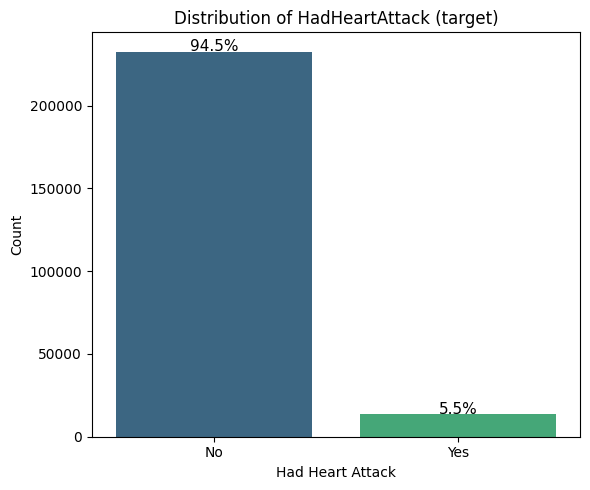

HadHeartAttack
No     232587
Yes     13435
Name: count, dtype: int64

Class imbalance ratio: 17.3:1


In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(x='HadHeartAttack', data=data, palette='viridis')
plt.title('Distribution of HadHeartAttack (target)')
plt.xlabel('Had Heart Attack')
plt.ylabel('Count')

total = len(data)
for p in plt.gca().patches:
    pct = f"{100 * p.get_height() / total:.1f}%"
    plt.gca().annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height() + 500),
                       ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print(data['HadHeartAttack'].value_counts())
print(f"\nClass imbalance ratio: {round(232587/13435, 1)}:1")

# Statistical summary

In [ ]:
print(data[numeric_cols].agg(['mean', 'median', 'std', 'skew', 'kurt']).round(2))

        PhysicalHealthDays  MentalHealthDays  SleepHours  HeightInMeters  \
mean                  4.12              4.17        7.02            1.71   
median                0.00              0.00        7.00            1.70   
std                   8.41              8.10        1.44            0.11   
skew                  2.28              2.22        0.56            0.03   
kurt                  3.97              3.86        7.21            0.01   

        WeightInKilograms    BMI  
mean                83.62  28.67  
median              81.65  27.46  
std                 21.32   6.51  
skew                 1.02   1.33  
kurt                 2.34   3.90  


#Univariate: histograms

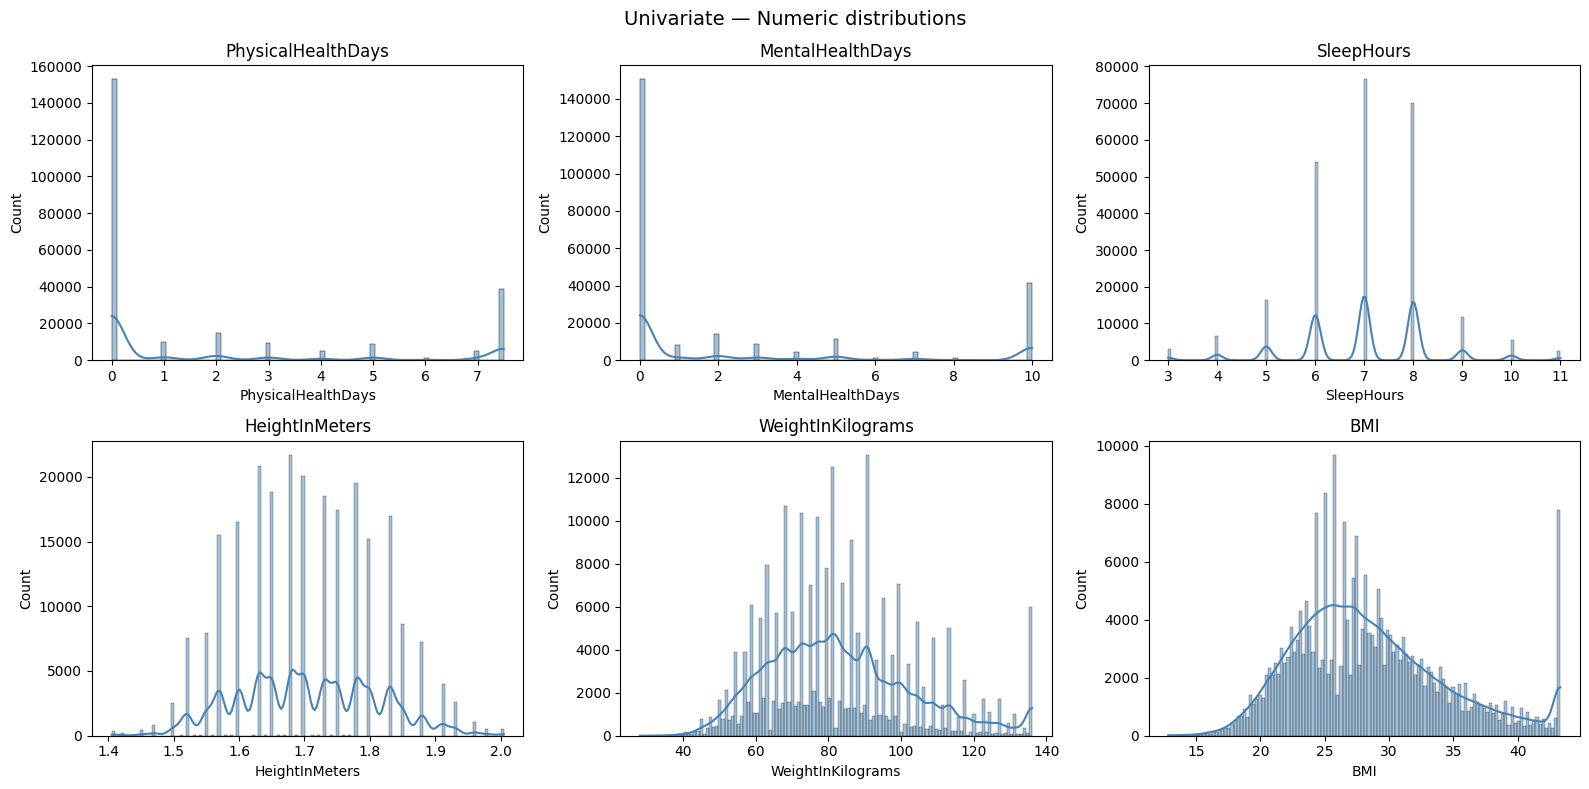

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(data_clean[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.suptitle('Univariate — Numeric distributions', fontsize=14)
plt.tight_layout()
plt.show()

#Univariate: boxplots

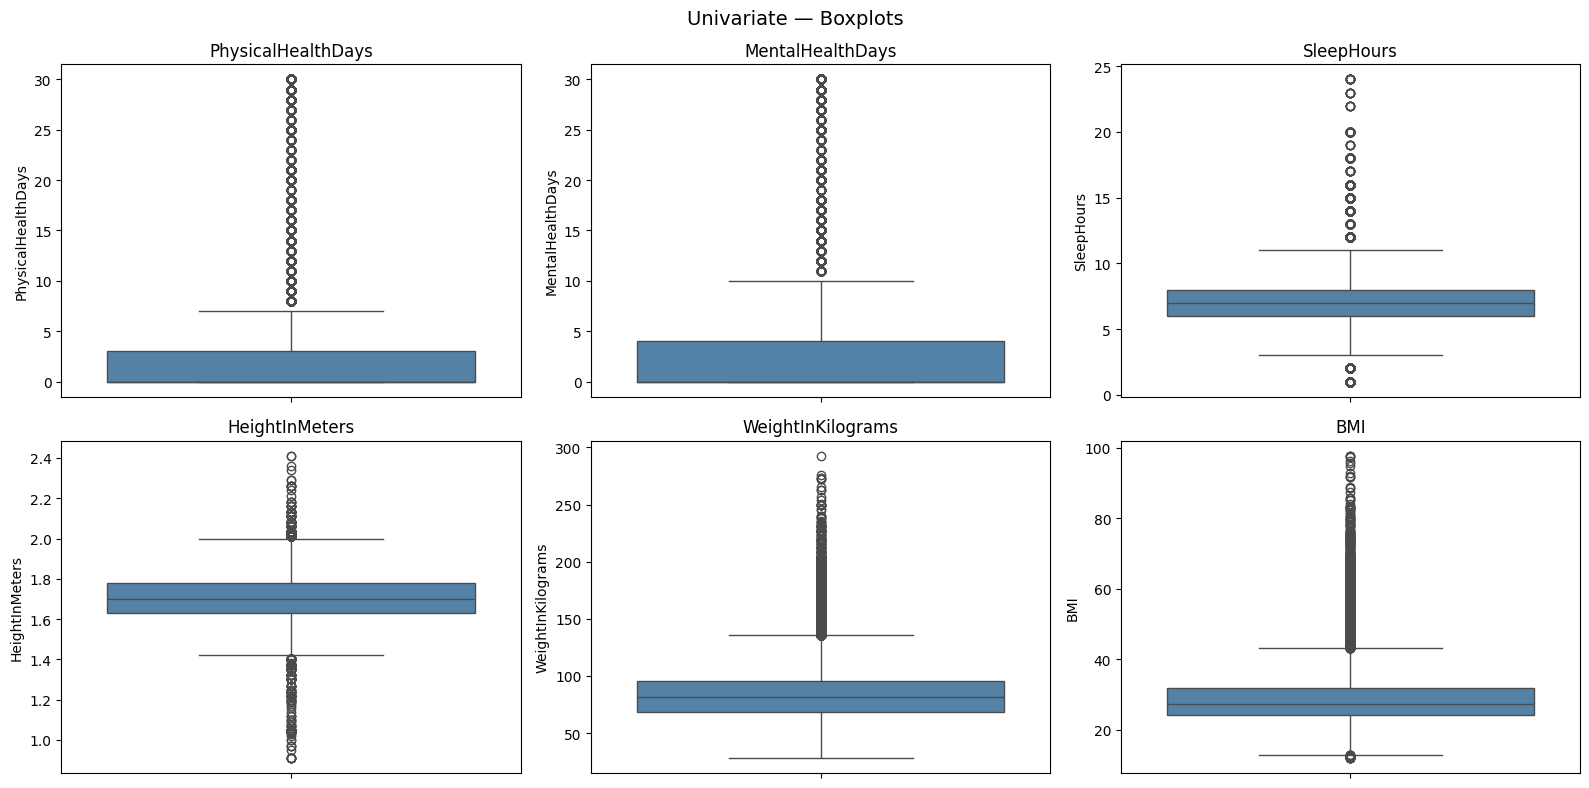

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=data[col], ax=ax, color='steelblue')
    ax.set_title(col)
plt.suptitle('Univariate — Boxplots', fontsize=14)
plt.tight_layout()
plt.show()

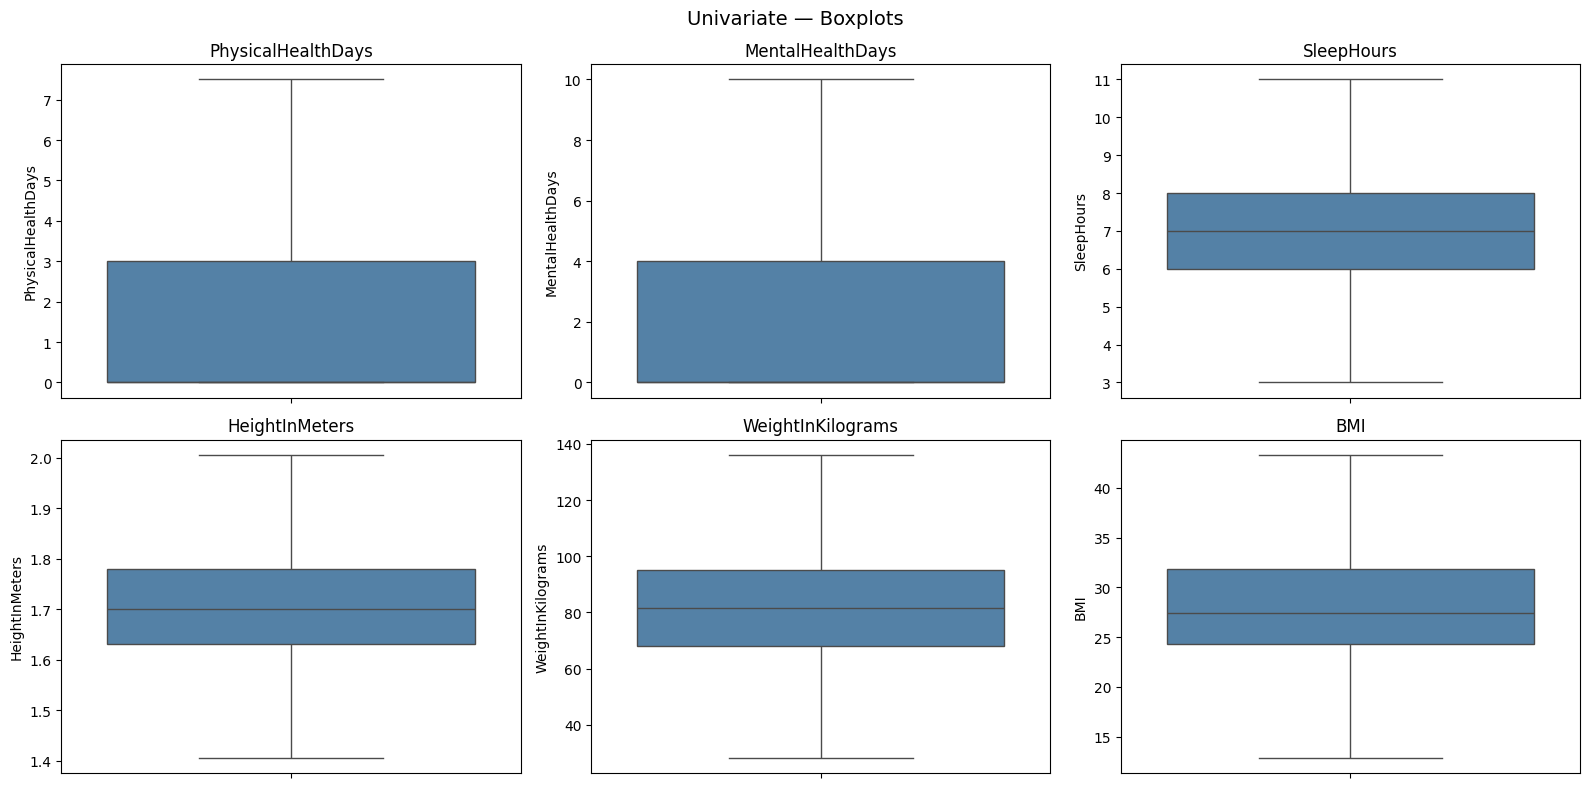

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=data_clean[col], ax=ax, color='steelblue')
    ax.set_title(col)
plt.suptitle('Univariate — Boxplots', fontsize=14)
plt.tight_layout()
plt.show()

# violin plots

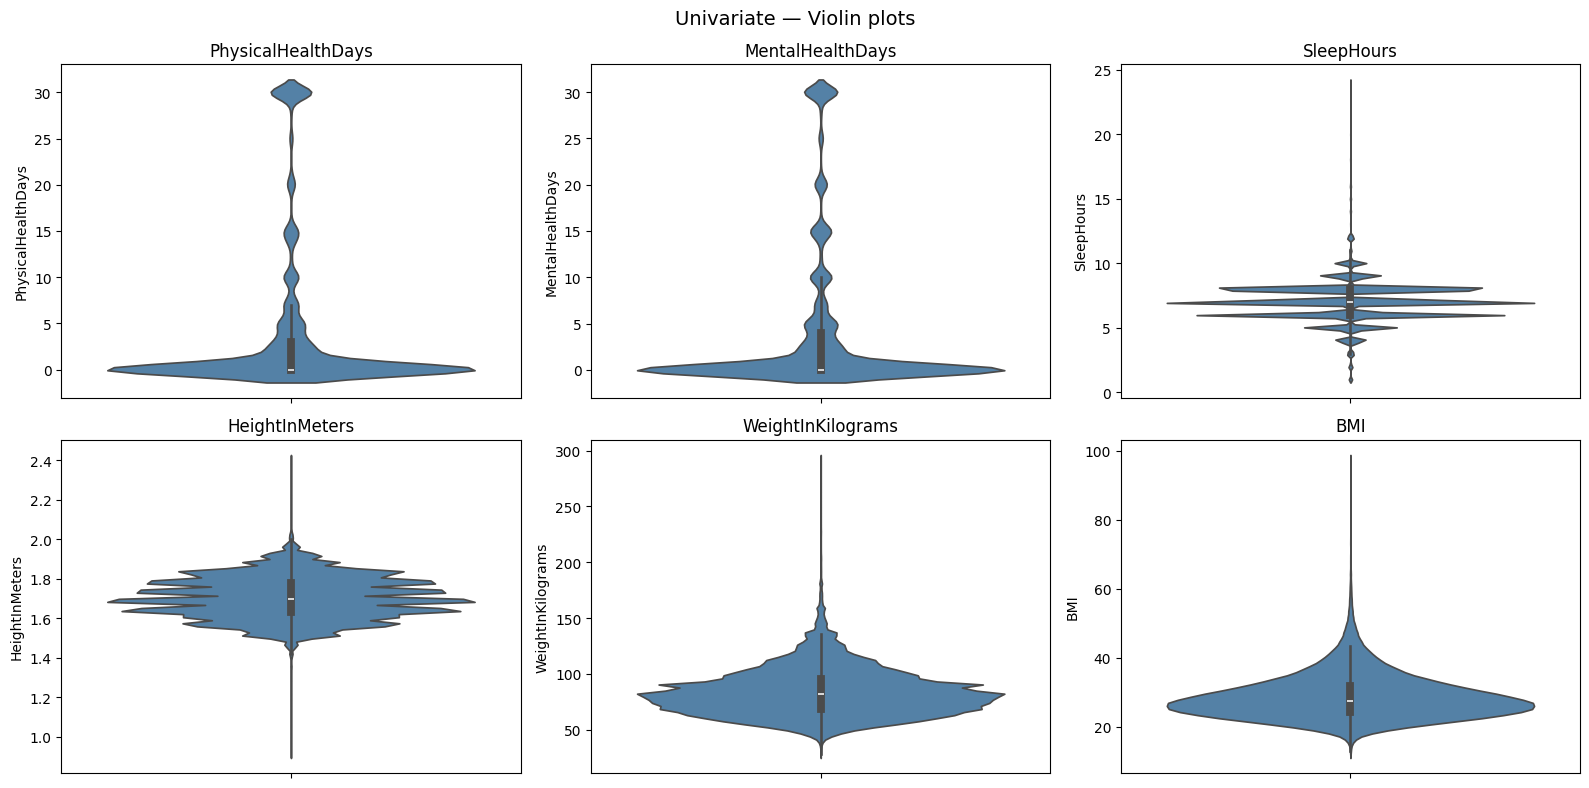

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.violinplot(y=data[col], ax=ax, color='steelblue')
    ax.set_title(col)
plt.suptitle('Univariate — Violin plots', fontsize=14)
plt.tight_layout()
plt.show()

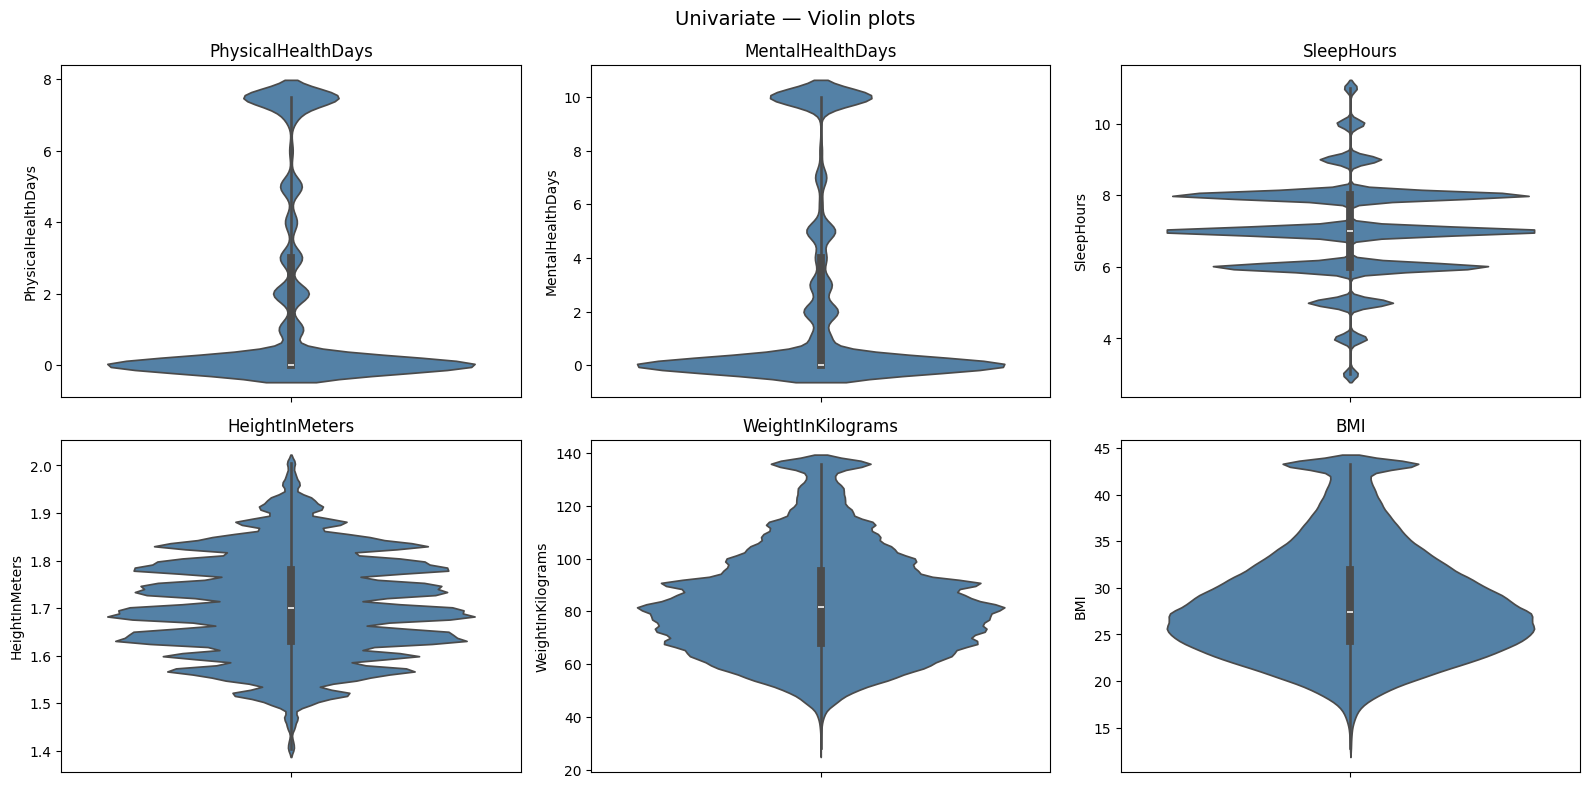

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.violinplot(y=data_clean[col], ax=ax, color='steelblue')
    ax.set_title(col)
plt.suptitle('Univariate — Violin plots', fontsize=14)
plt.tight_layout()
plt.show()

#Univariate: categorical countplots

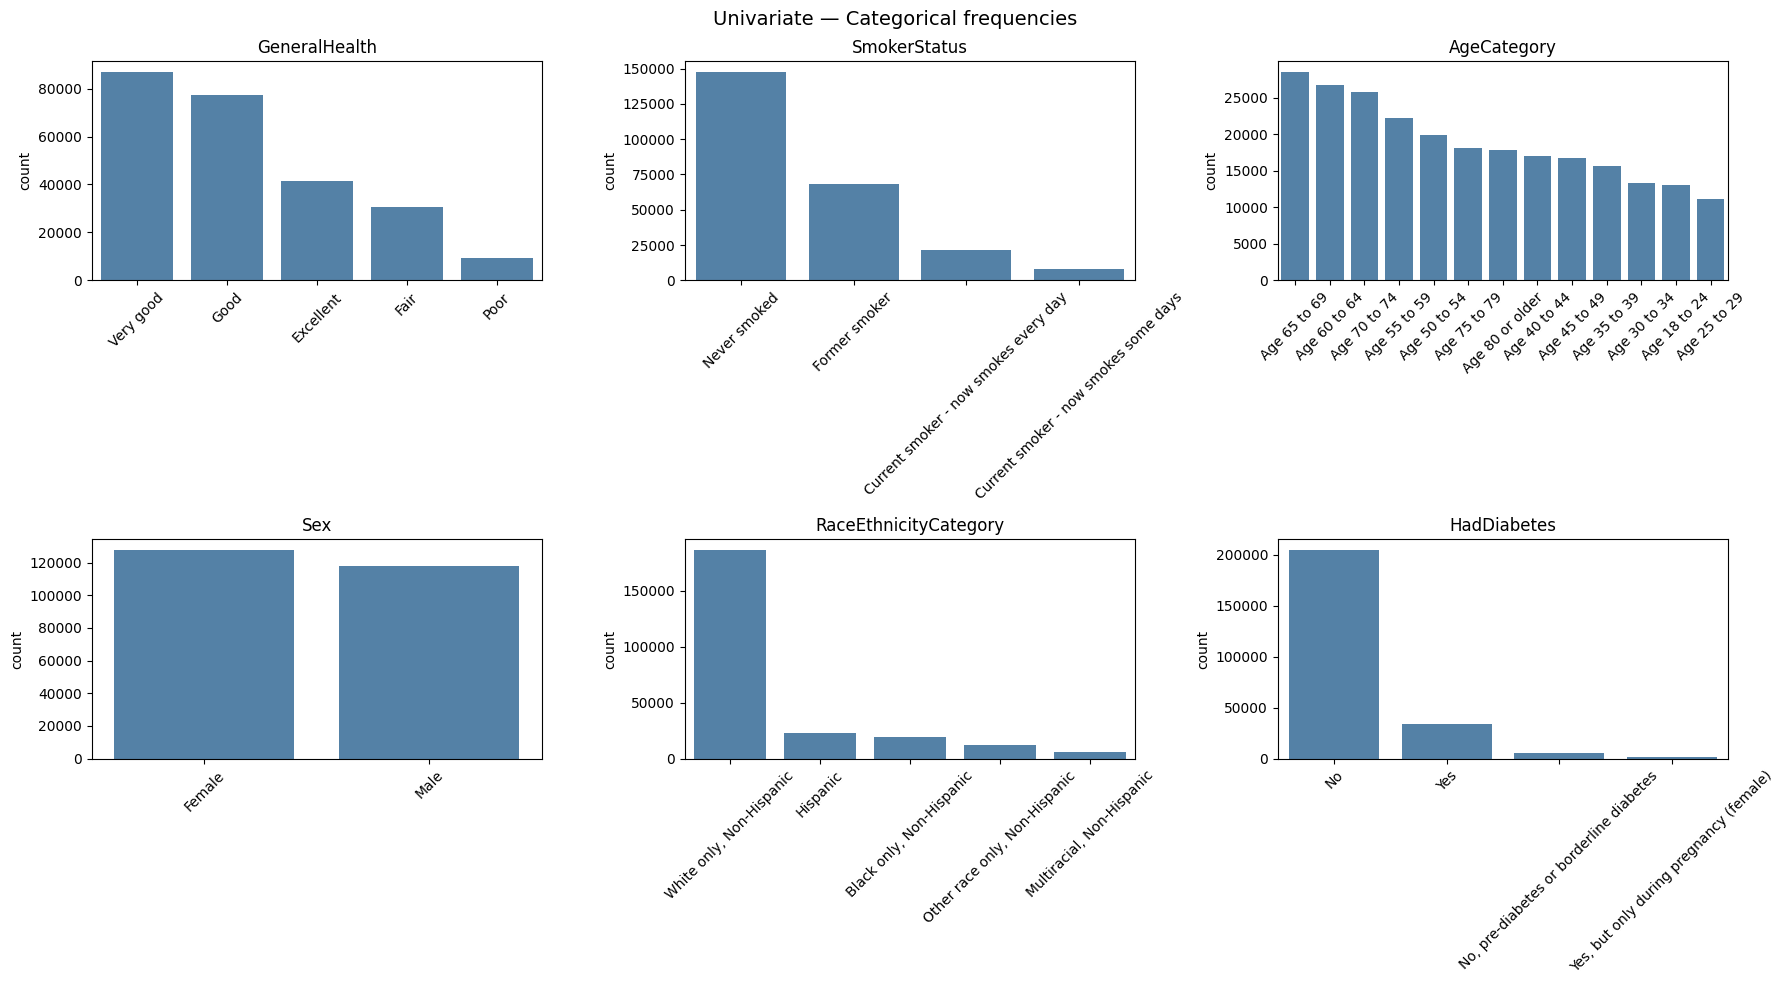

In [ ]:
cat_plot_cols = ['GeneralHealth', 'SmokerStatus', 'AgeCategory',
                 'Sex', 'RaceEthnicityCategory', 'HadDiabetes']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), cat_plot_cols):
    order = data[col].value_counts().index
    sns.countplot(x=col, data=data, order=order, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
plt.suptitle('Univariate — Categorical frequencies', fontsize=14)
plt.tight_layout()
plt.show()

#Multivariate: numeric vs HadHeartAttack

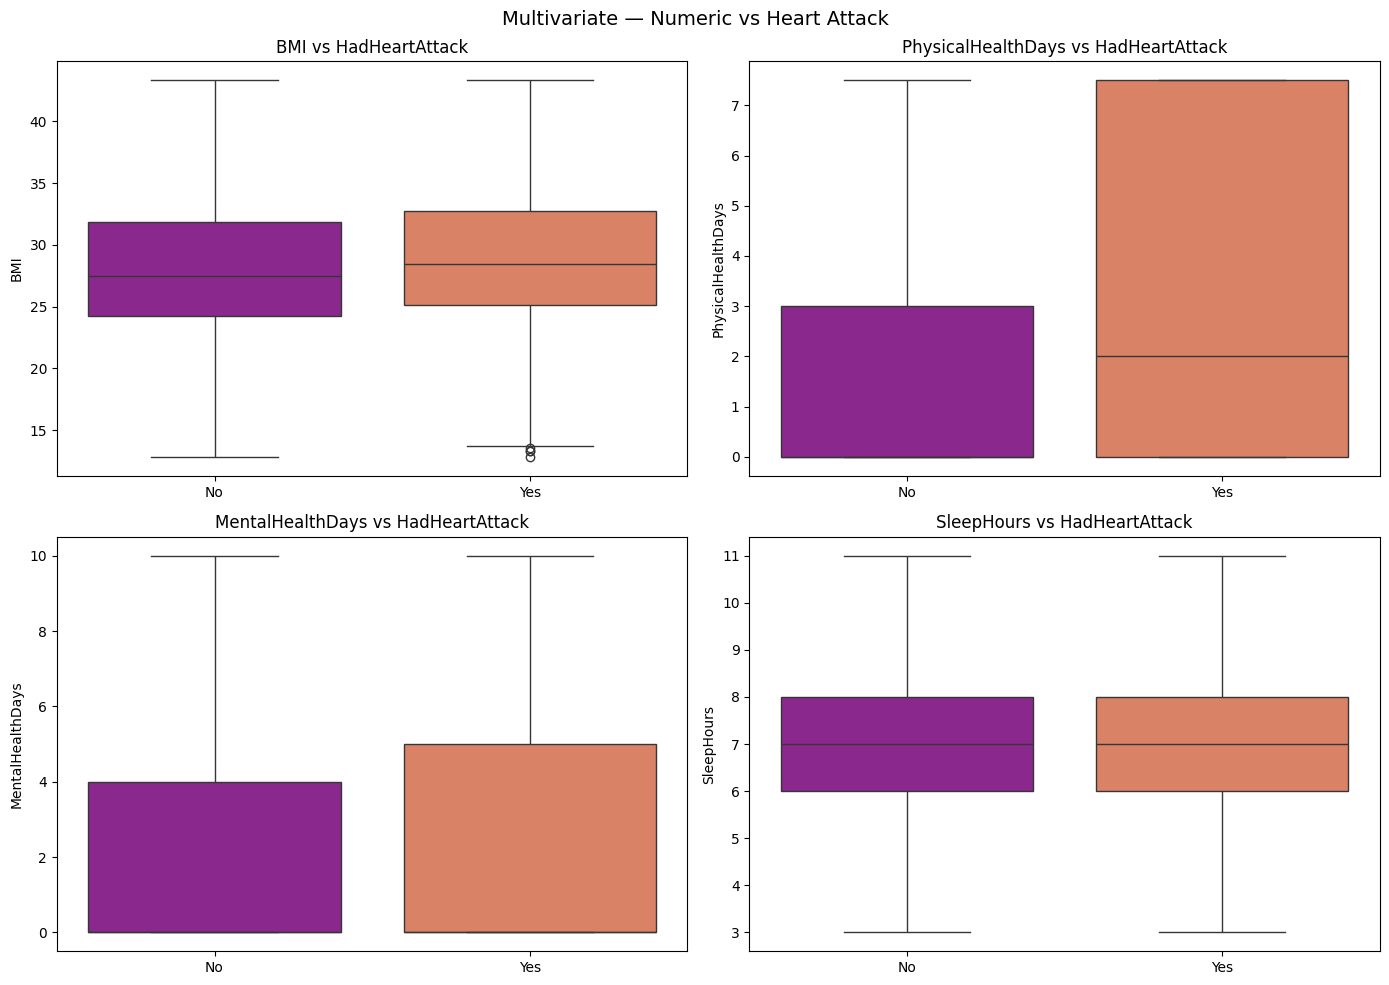

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), ['BMI', 'PhysicalHealthDays',
                                     'MentalHealthDays', 'SleepHours']):
    sns.boxplot(x='HadHeartAttack', y=col, data=data_clean, palette='plasma', ax=ax)
    ax.set_title(f'{col} vs HadHeartAttack')
    ax.set_xlabel('')
plt.suptitle('Multivariate — Numeric vs Heart Attack', fontsize=14)
plt.tight_layout()
plt.show()

#Multivariate: categorical vs HadHeartAttack

In [ ]:
categorical_cols = ['HadStroke', 'DifficultyWalking', 'Sex', 'AgeCategory',
                    'RaceEthnicityCategory', 'HadDiabetes', 'GeneralHealth',
                    'SmokerStatus', 'AlcoholDrinkers', 'PhysicalActivities',
                    'HadAsthma', 'HadKidneyDisease', 'HadSkinCancer']

n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='HadHeartAttack', data=data,
                  palette='viridis', ax=axes[i])
    axes[i].set_title(f'{col} vs HadHeartAttack')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Multivariate — Categorical vs Heart Attack', fontsize=14)
plt.tight_layout()
plt.show()

#Multivariate: correlation heatmap

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(data[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Numeric columns correlation heatmap')
plt.tight_layout()
plt.show()

#Multivariate: pairplot

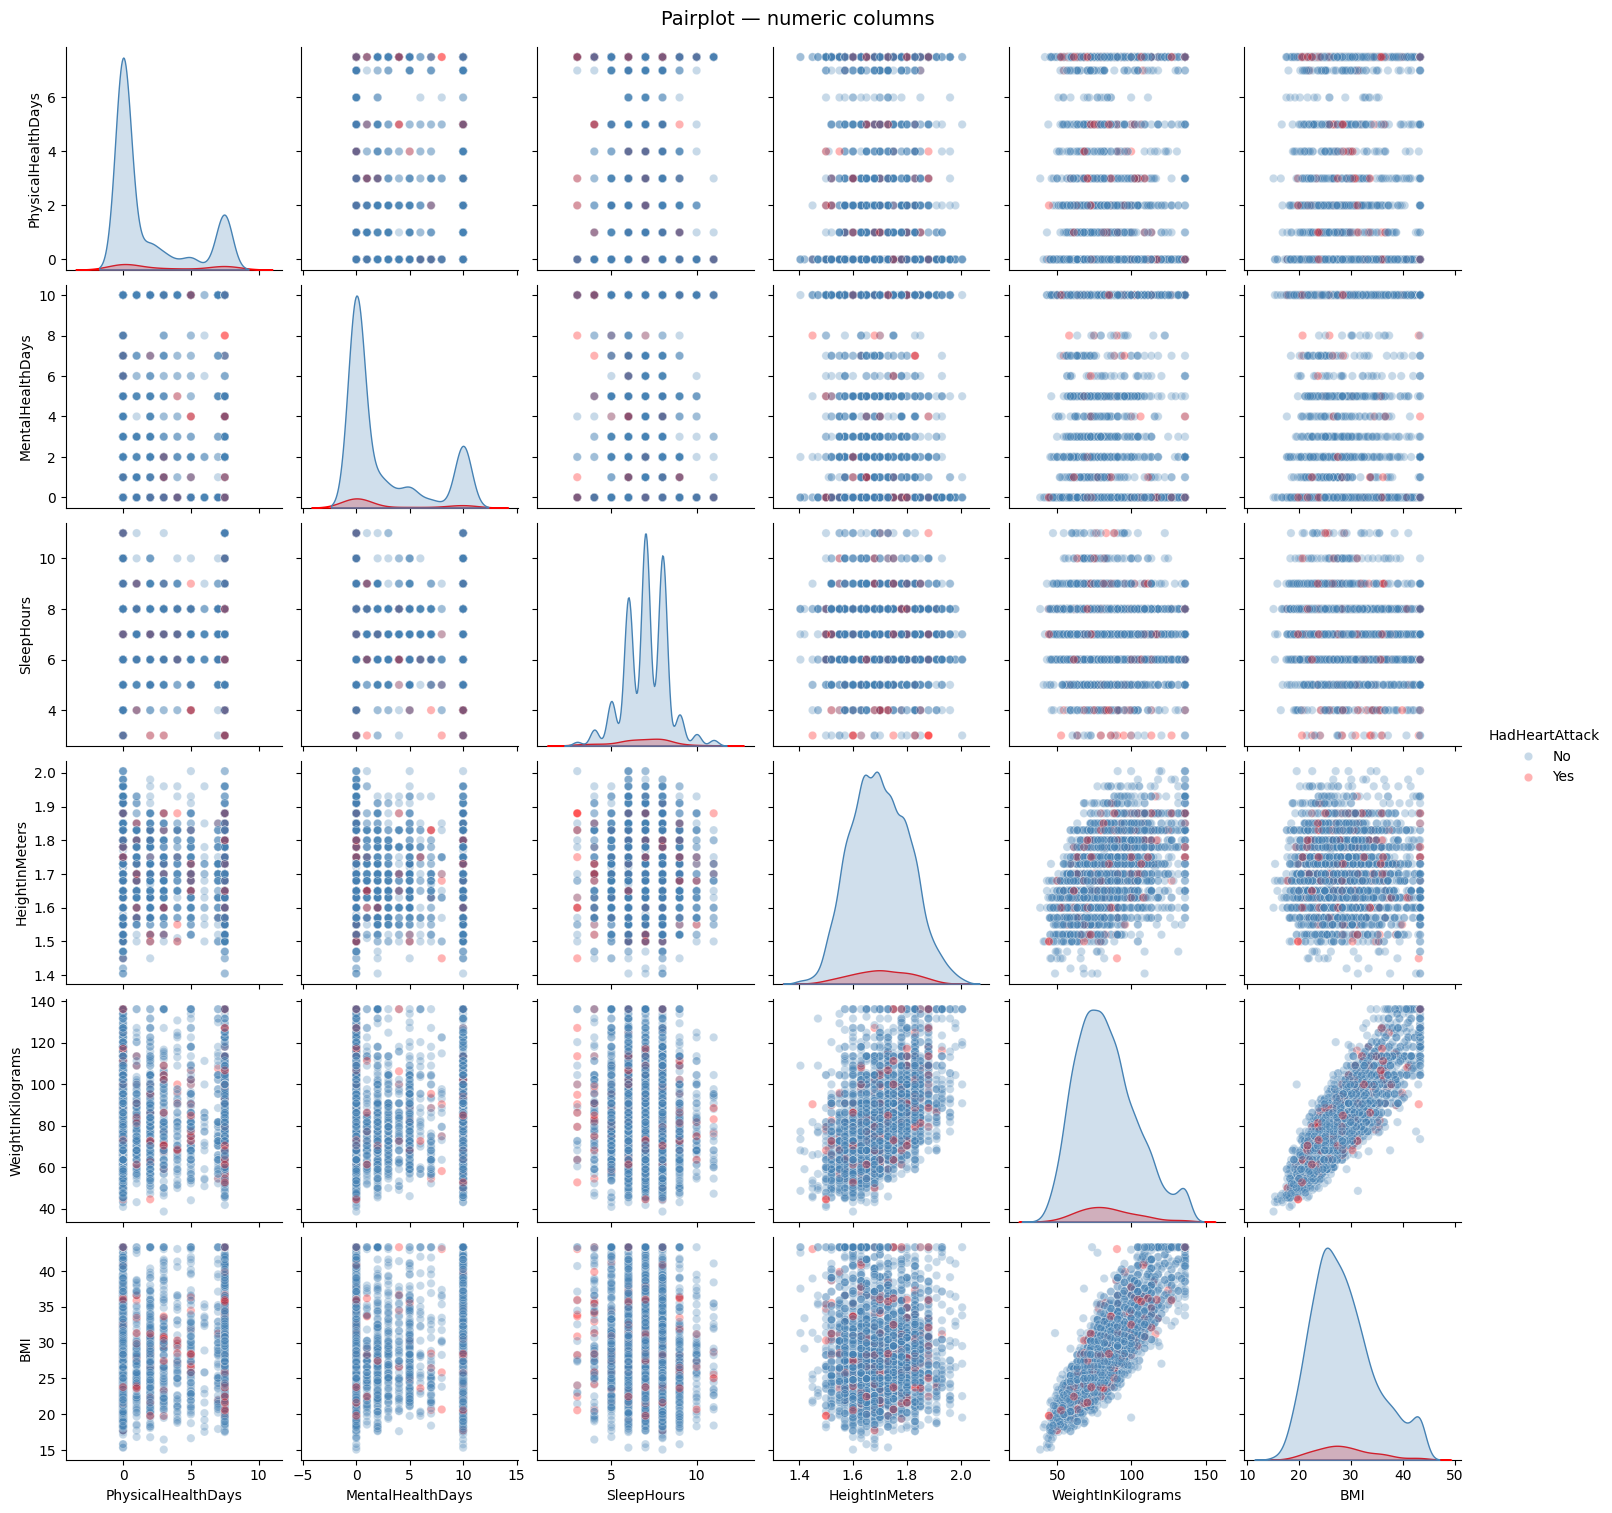

In [ ]:
sample = data_clean[numeric_cols + ['HadHeartAttack']].sample(3000, random_state=42).copy()

sns.pairplot(sample, hue='HadHeartAttack',
             palette={'Yes': 'red', 'No': 'steelblue'},
             plot_kws={'alpha': 0.3}, diag_kind='kde')
plt.suptitle('Pairplot — numeric columns', y=1.01, fontsize=14)
plt.show()

#Multivariate: joint distribution plot

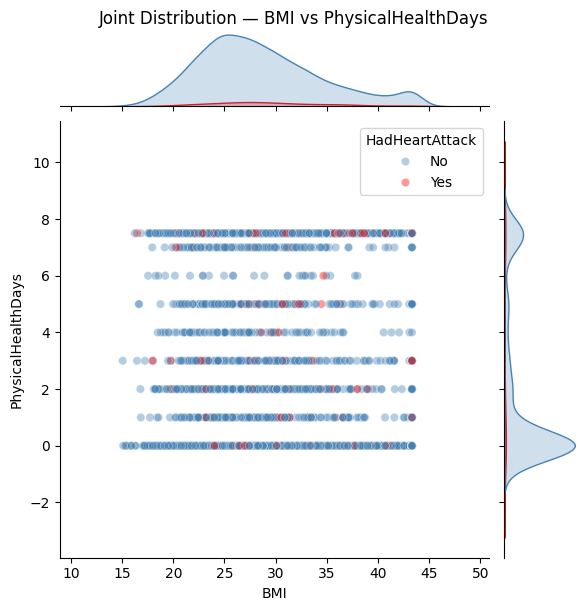

In [ ]:
sns.jointplot(data=data_clean.sample(5000, random_state=42),
              x='BMI', y='PhysicalHealthDays',
              hue='HadHeartAttack',
              palette={'Yes': 'red', 'No': 'steelblue'},
              alpha=0.4)
plt.suptitle('Joint Distribution — BMI vs PhysicalHealthDays', y=1.01)
plt.show()

#Multivariate: parallel coordinates

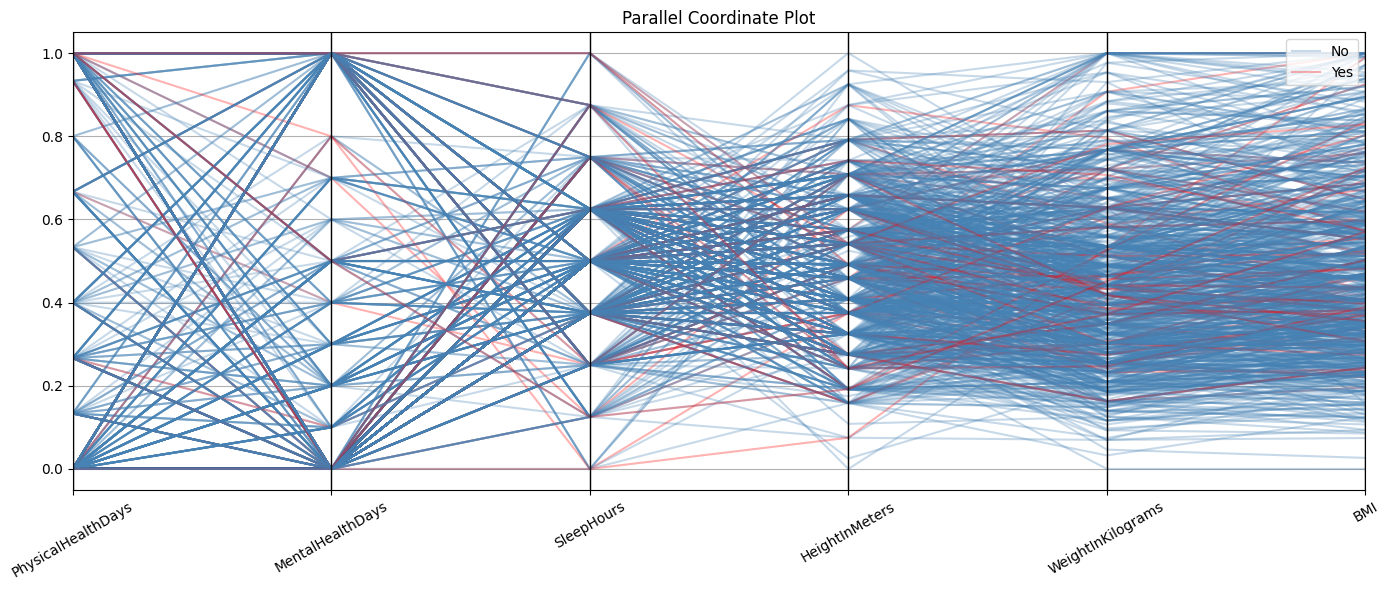

In [ ]:
from pandas.plotting import parallel_coordinates

sample_pc = data_clean[numeric_cols + ['HadHeartAttack']].sample(1000, random_state=42).copy()
sample_pc[numeric_cols] = MinMaxScaler().fit_transform(sample_pc[numeric_cols])

plt.figure(figsize=(14, 6))
parallel_coordinates(sample_pc, 'HadHeartAttack',
                     color=['steelblue', 'red'], alpha=0.3)
plt.xticks(rotation=30)
plt.title('Parallel Coordinate Plot')
plt.tight_layout()
plt.show()

#Multivariate: cluster map

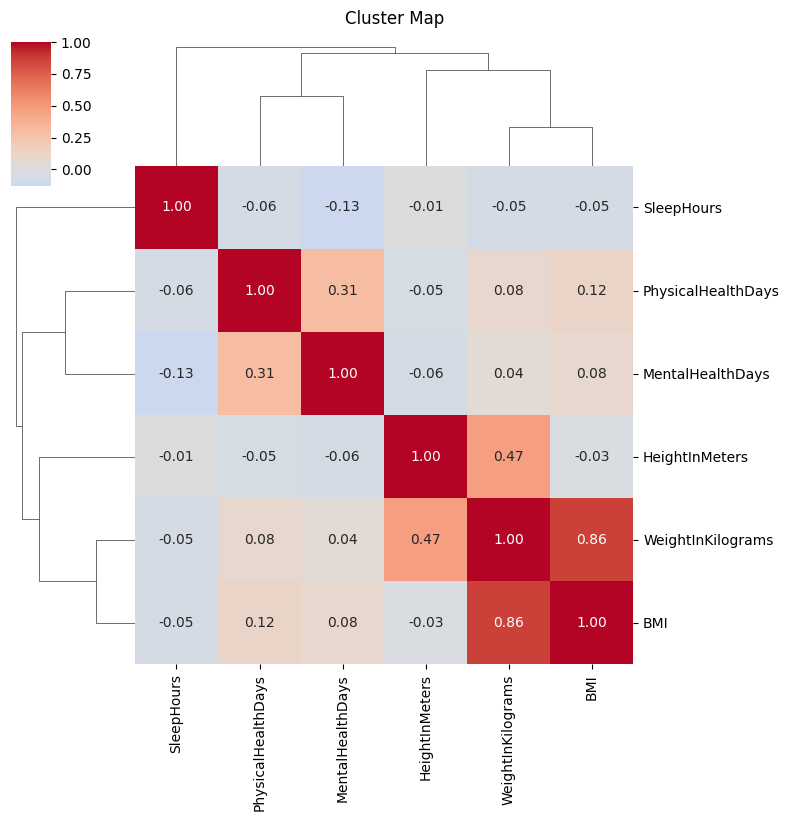

In [ ]:
sns.clustermap(data[numeric_cols].corr(), annot=True, fmt='.2f',
               cmap='coolwarm', center=0, figsize=(8, 8))
plt.suptitle('Cluster Map', y=1.02)
plt.show()

#Correlation with target

In [ ]:
temp = data.copy()
temp['HeartAttack_enc'] = (temp['HadHeartAttack'] == 'Yes').astype(int)
data_enc = pd.get_dummies(temp.drop(columns=['HadHeartAttack']), drop_first=True)

corr = data_enc.corr()['HeartAttack_enc'] \
               .drop('HeartAttack_enc') \
               .sort_values(ascending=False)

print("Top 10 positively correlated:")
print(corr.head(10))
print("\nTop 10 negatively correlated:")
print(corr.tail(10))

del temp, data_enc

Top 10 positively correlated:
HadAngina_Yes            0.445903
HadStroke_Yes            0.177137
ChestScan_Yes            0.167760
DifficultyWalking_Yes    0.159878
HadDiabetes_Yes          0.145868
GeneralHealth_Poor       0.140607
PhysicalHealthDays       0.133420
HadCOPD_Yes              0.133223
RemovedTeeth_All         0.120564
PneumoVaxEver_Yes        0.119955
Name: HeartAttack_enc, dtype: float64

Top 10 negatively correlated:
LastCheckupTime_Within past 2 years (1 year but less than 2 years ago)   -0.041811
AgeCategory_Age 25 to 29                                                 -0.048216
AgeCategory_Age 40 to 44                                                 -0.049331
AgeCategory_Age 30 to 34                                                 -0.050453
AgeCategory_Age 35 to 39                                                 -0.051119
AlcoholDrinkers_Yes                                                      -0.074181
PhysicalActivities_Yes                                         

#Encode X and define y

In [ ]:
# ── Target ────────────────────────────────────────────────────────────────
y = (data_clean['HadHeartAttack'] == 'Yes').astype(int)
df = data_clean.drop(columns=['HadHeartAttack']).copy()

# ── Binary Yes/No columns ─────────────────────────────────────────────────
binary_cols = ['HadStroke', 'DifficultyWalking', 'AlcoholDrinkers',
               'PhysicalActivities', 'HadAsthma', 'HadKidneyDisease',
               'HadSkinCancer', 'HadAngina', 'ChestScan',
               'FluVaxLast12', 'PneumoVaxEver', 'HIVTesting',
               'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
               'DifficultyConcentrating', 'DifficultyDressingBathing',
               'DifficultyErrands', 'HighRiskLastYear']

# Only apply to columns that actually exist
binary_cols = [c for c in binary_cols if c in df.columns]
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['Sex'] = df['Sex'].map({'Male': 1, 'Female': 0})

# ── Ordinal encoding ──────────────────────────────────────────────────────
age_order = ['Age 18 to 24','Age 25 to 29','Age 30 to 34','Age 35 to 39',
             'Age 40 to 44','Age 45 to 49','Age 50 to 54','Age 55 to 59',
             'Age 60 to 64','Age 65 to 69','Age 70 to 74','Age 75 to 79',
             'Age 80 or older']
if 'AgeCategory' in df.columns:
    df['AgeCategory'] = (df['AgeCategory'].astype('category')
                         .cat.set_categories(age_order, ordered=True).cat.codes)

health_order = ['Poor','Fair','Good','Very good','Excellent']
if 'GeneralHealth' in df.columns:
    df['GeneralHealth'] = (df['GeneralHealth'].astype('category')
                           .cat.set_categories(health_order, ordered=True).cat.codes)

# ── One-hot encode remaining categoricals ─────────────────────────────────
object_cols = df.select_dtypes(include='object').columns.tolist()
X = pd.get_dummies(df, columns=object_cols, drop_first=True)
X = X.astype(float)  # ensure all numeric for SMOTE

print(f'X shape: {X.shape}')
print(f'y distribution:\n{y.value_counts()}')


X shape: (246022, 107)
y distribution:
HadHeartAttack
0    232587
1     13435
Name: count, dtype: int64


#Feature selection

#Mutual Information — numeric

In [ ]:
numeric_cols_fs = ['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours',
                   'HeightInMeters', 'WeightInKilograms', 'BMI']
cat_cols_fs = [c for c in X.columns if c not in numeric_cols_fs]

mi_num = mutual_info_classif(X[numeric_cols_fs], y, random_state=42)
mi_num_scores = pd.Series(mi_num, index=numeric_cols_fs).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
mi_num_scores.plot(kind='bar', color='teal')
plt.title('Mutual Information — Numeric features vs HadHeartAttack')
plt.ylabel('MI Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


#Mutual Information (categorical)

In [ ]:
mi_cat = mutual_info_classif(X[cat_cols_fs], y, random_state=42)
mi_cat_scores = pd.Series(mi_cat, index=cat_cols_fs).sort_values(ascending=False)

# Filter out near-zero MI scores
MI_PLOT_THRESHOLD = 0.01  # adjust as needed
mi_cat_scores_filtered = mi_cat_scores[mi_cat_scores > MI_PLOT_THRESHOLD]

plt.figure(figsize=(18, 5))
mi_cat_scores_filtered.plot(kind='bar', color='teal')
plt.title(f'Mutual Information — Categorical features vs HadHeartAttack\n(showing {len(mi_cat_scores_filtered)} / {len(mi_cat_scores)} features with MI > {MI_PLOT_THRESHOLD})')
plt.ylabel('MI Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Dropped from plot: {len(mi_cat_scores) - len(mi_cat_scores_filtered)} near-zero features")

#ANOVA F-test (numeric only)

In [ ]:
f_num, _ = f_classif(X[numeric_cols_fs], y)
f_scores = pd.Series(f_num, index=numeric_cols_fs).sort_values(ascending=False)

F_PLOT_THRESHOLD = 1.0  # F < 1 is essentially noise
f_scores_filtered = f_scores[f_scores > F_PLOT_THRESHOLD]

plt.figure(figsize=(8, 4))
f_scores_filtered.plot(kind='bar', color='red')
plt.title(f'ANOVA F-test — Numeric features vs HadHeartAttack\n(showing {len(f_scores_filtered)} / {len(f_scores)} features with F > {F_PLOT_THRESHOLD})')
plt.ylabel('F Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(f"Dropped from plot: {len(f_scores) - len(f_scores_filtered)} near-zero features")

#Chi-square (categorical only)

In [ ]:
X_cat_scaled = MinMaxScaler().fit_transform(X[cat_cols_fs])
chi2_cat, _ = chi2(X_cat_scaled, y)
chi2_scores = pd.Series(chi2_cat, index=cat_cols_fs).sort_values(ascending=False)

CHI2_PLOT_THRESHOLD =  1000

chi2_scores_filtered = chi2_scores[chi2_scores > CHI2_PLOT_THRESHOLD]

plt.figure(figsize=(18, 5))
chi2_scores_filtered.plot(kind='bar', color='orange')
plt.title(f'Chi-square — Categorical features vs HadHeartAttack\n(showing {len(chi2_scores_filtered)} / {len(chi2_scores)} features with Chi2 > {CHI2_PLOT_THRESHOLD})')
plt.ylabel('Chi2 Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
num_scores = pd.DataFrame({'feature': numeric_cols_fs, 'type': 'numeric',
                            'MI': mi_num, 'F_ANOVA': f_num, 'Chi2': np.nan})
cat_scores = pd.DataFrame({'feature': cat_cols_fs, 'type': 'categorical',
                            'MI': mi_cat, 'F_ANOVA': np.nan, 'Chi2': chi2_cat})

all_scores = pd.concat([num_scores, cat_scores], ignore_index=True)
for col in ['MI', 'F_ANOVA', 'Chi2']:
    mn, mx = all_scores[col].min(), all_scores[col].max()
    all_scores[col + '_norm'] = (all_scores[col] - mn) / (mx - mn)

all_scores['composite'] = all_scores[['MI_norm','F_ANOVA_norm','Chi2_norm']].mean(axis=1, skipna=True)
all_scores = all_scores.sort_values('composite', ascending=False).reset_index(drop=True)
all_scores['rank'] = all_scores.index + 1

THRESHOLD = 0.03
selected_features = all_scores[all_scores['composite'] >= THRESHOLD]['feature'].tolist()
X_selected = X[selected_features]

print(f'Features kept : {len(selected_features)} / {X.shape[1]}')
print(f'Features dropped (composite < {THRESHOLD}): {X.shape[1] - len(selected_features)}')
print('\nTop 20:')
print(all_scores[['rank','feature','type','composite']].head(20).to_string(index=False))


In [ ]:
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_selected, y, test_size=0.20, random_state=42, stratify=y)

print('Before SMOTE:')
print(y_train_raw.value_counts())
print(f'  Ratio: {y_train_raw.value_counts()[0]/y_train_raw.value_counts()[1]:.1f}:1')


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.3, random_state=42)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print('After SMOTE:')
print(pd.Series(y_train).value_counts())
print(f'  Ratio: {pd.Series(y_train).value_counts()[0]/pd.Series(y_train).value_counts()[1]:.1f}:1')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (title, yy) in zip(axes, [('Before SMOTE (train)', y_train_raw),
                                    ('After SMOTE (train)',  pd.Series(y_train))]):
    vc = yy.value_counts()
    ax.bar(['No (0)', 'Yes (1)'], [vc.get(0,0), vc.get(1,0)],
           color=['steelblue', 'tomato'])
    ax.set_title(title)
    ax.set_ylabel('Count')

plt.suptitle('Class Distribution — Before vs After SMOTE', fontsize=13)
plt.tight_layout()
plt.show()

#Train CatBoost Model

In [ ]:
import lightgbm as lgb

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostClassifier

In [ ]:
X_train_df = pd.DataFrame(X_train, columns=X_selected.columns)
X_test_df  = pd.DataFrame(X_test,  columns=X_selected.columns)

neg, pos = pd.Series(y_train).value_counts()[0], pd.Series(y_train).value_counts()[1]
scale_pos = neg / pos
print(f'scale_pos_weight = {scale_pos:.2f}')

model = CatBoostClassifier(
    iterations=600,
    depth=7,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    scale_pos_weight=scale_pos,
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)

model.fit(
    X_train_df, y_train,
    eval_set=(X_test_df, y_test),
    use_best_model=True
)

print('Best iteration:', model.best_iteration_)


#Evaluation: classification report & confusion matrix

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

In [ ]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=['No Heart Attack', 'Heart Attack'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)

plt.title("Confusion Matrix - CatBoost Model")
plt.show()

#Evaluation: ROC & Precision-Recall curves

In [ ]:
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}")

precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print(f"PR-AUC Score  : {pr_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name='CatBoost Model')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('ROC Curve')

axes[1].plot(recall, precision, color='darkorange')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
axes[1].fill_between(recall, precision, alpha=0.2, color='darkorange')

plt.tight_layout()
plt.show()

#SHAP

In [ ]:
import shap

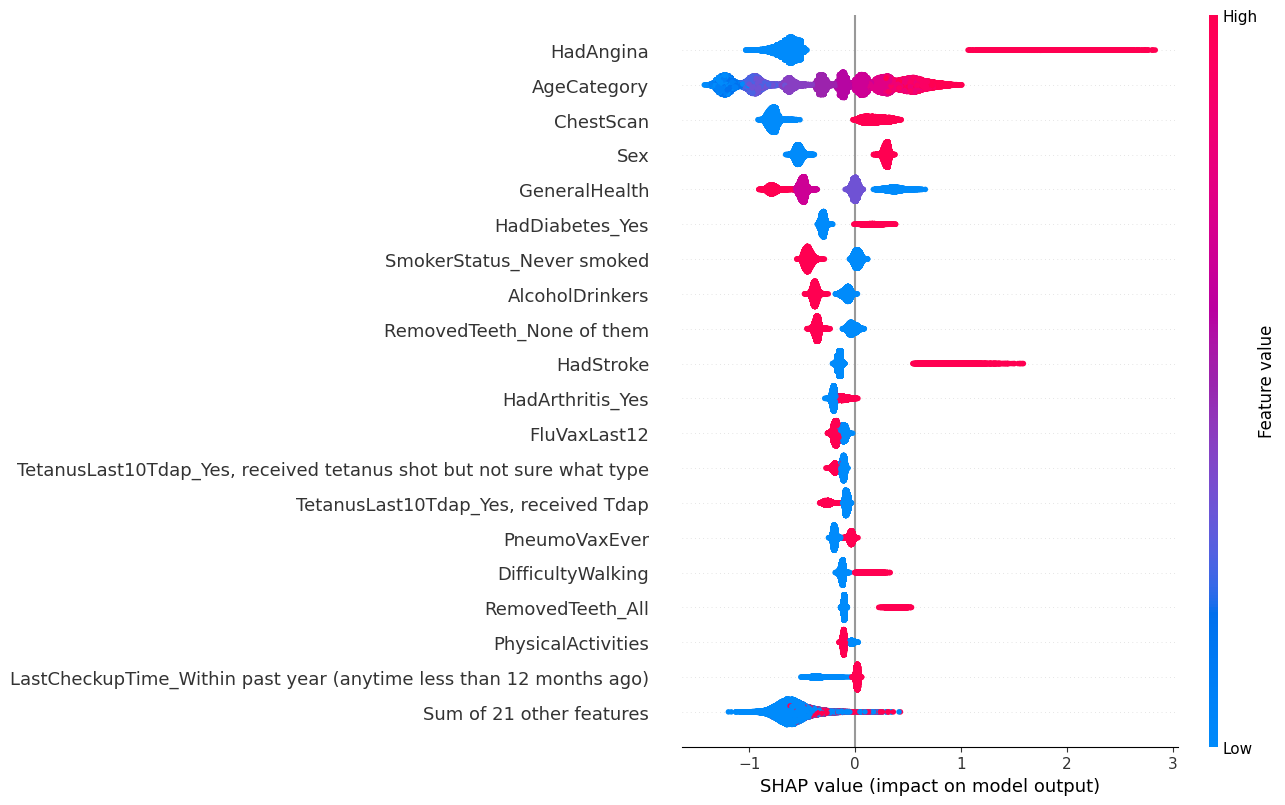

In [ ]:
explainer   = shap.Explainer(model)
shap_values = explainer(X_test_df)

shap.plots.beeswarm(shap_values, max_display=20)

#LIME

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_df.values,
    feature_names=X_train_df.columns.tolist(),
    class_names=['No Heart Attack', 'Heart Attack'],
    mode='classification'
)

pos_idx = y_test[y_test == 1].index[0]
instance = X_test_df.loc[pos_idx].values

exp = lime_explainer.explain_instance(
    data_row=instance,
    predict_fn=model.predict_proba,
    num_features=15
)

exp.show_in_notebook(show_table=True)


In [ ]:
from sklearn.inspection import PartialDependenceDisplay

# Additional Installs & Imports

In [ ]:
!pip install lime shap --quiet
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.base import BaseEstimator, ClassifierMixin
import shap
import lime
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## CatBoost — Permutation Importance

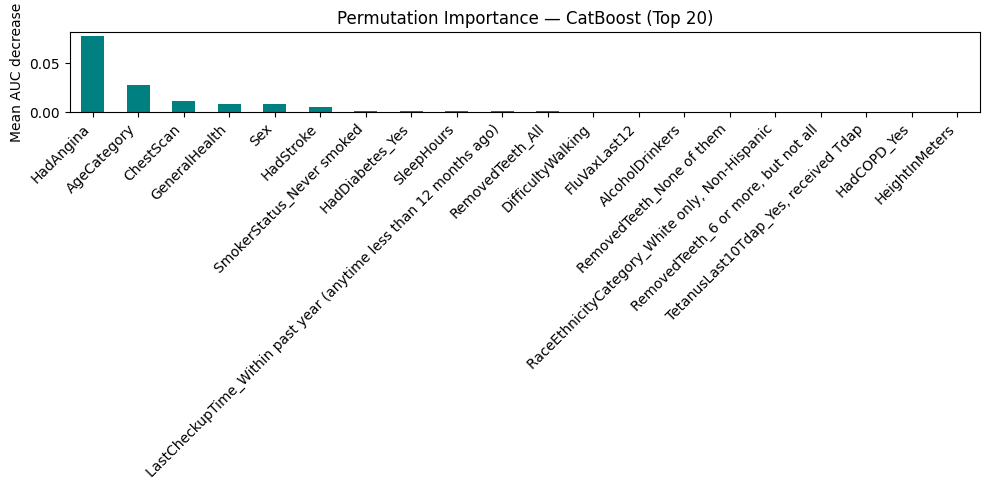

In [ ]:
from sklearn.inspection import permutation_importance

perm_cb = permutation_importance(
    model, X_test_df, y_test,
    n_repeats=10, random_state=42, scoring='roc_auc'
)

perm_cb_series = pd.Series(perm_cb.importances_mean, index=X_test_df.columns) \
                   .sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 5))
perm_cb_series.plot(kind='bar', color='teal')
plt.title('Permutation Importance — CatBoost (Top 20)')
plt.ylabel('Mean AUC decrease')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## CatBoost — Partial Dependence Plot (PDP)

ValueError: 'estimator' must be a fitted regressor or classifier.

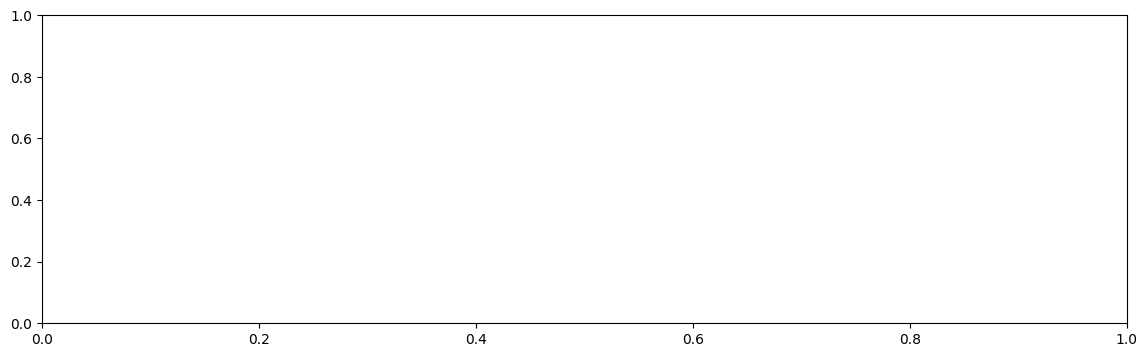

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
from sklearn.base import BaseEstimator, ClassifierMixin

# Wrapper to make CatBoost compatible with sklearn PDP
class CatBoostWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model
        self.classes_ = np.array([0, 1])
    def fit(self, X, y):
        return self
    def predict(self, X):
        return self.model.predict(X).flatten().astype(int)
    def predict_proba(self, X):
        return self.model.predict_proba(X)

wrapped_cb = CatBoostWrapper(model)

numeric_top_cb = [f for f in all_scores['feature'].tolist() if f in numeric_cols_fs][:4]

fig, ax = plt.subplots(figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    wrapped_cb, X_test_df, numeric_top_cb,
    ax=ax, grid_resolution=50,
    response_method='predict_proba'
)
plt.suptitle('PDP — CatBoost', fontsize=14)
plt.tight_layout()
plt.show()

# Train SVM Model

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    probability=True,   # needed for SHAP / LIME predict_proba
    class_weight='balanced',
    random_state=42
)

# SVM is slow on large data — use a subsample for training
from sklearn.utils import resample
X_svm_train, y_svm_train = resample(
    X_train_df, pd.Series(y_train),
    n_samples=10000, random_state=42, stratify=pd.Series(y_train)
)

svm_model.fit(X_svm_train, y_svm_train)
print("SVM training complete")

## SVM — Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

y_pred_svm   = svm_model.predict(X_test_df)
y_proba_svm  = svm_model.predict_proba(X_test_df)[:, 1]

print(classification_report(y_test, y_pred_svm))
print("AUC:", roc_auc_score(y_test, y_proba_svm))

cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Heart Attack', 'Heart Attack'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix - SVM Model")
plt.show()

## SVM — SHAP

In [ ]:
# Use a small background sample for KernelExplainer (SVM has no native SHAP)
X_bg_svm    = shap.sample(X_svm_train, 100, random_state=42)
X_shap_svm  = X_test_df.sample(200, random_state=42)

svm_shap_explainer = shap.KernelExplainer(svm_model.predict_proba, X_bg_svm)
svm_shap_values    = svm_shap_explainer.shap_values(X_shap_svm, nsamples=100)

# shap_values is a list [class0, class1] — plot class 1 (Heart Attack)
shap.summary_plot(svm_shap_values[1], X_shap_svm, plot_type='bar',
                  max_display=20, show=True)
plt.title("SHAP — SVM (class: Heart Attack)")
plt.tight_layout()
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

## SVM — LIME

In [ ]:
lime_explainer_svm = LimeTabularExplainer(
    training_data=X_svm_train.values,
    feature_names=X_svm_train.columns.tolist(),
    class_names=['No Heart Attack', 'Heart Attack'],
    mode='classification'
)

# Explain a positive instance from the test set
pos_idx_svm = y_test[y_test == 1].index[0]
instance_svm = X_test_df.loc[pos_idx_svm].values

exp_svm = lime_explainer_svm.explain_instance(
    data_row=instance_svm,
    predict_fn=svm_model.predict_proba,
    num_features=15
)

exp_svm.show_in_notebook(show_table=True)

## SVM — Permutation Importance

In [ ]:
# Use a subsample of test set — full test set is slow for SVM
X_perm_svm = X_test_df.sample(1000, random_state=42)
y_perm_svm = y_test.loc[X_perm_svm.index]

perm_svm = permutation_importance(
    svm_model, X_perm_svm, y_perm_svm,
    n_repeats=10, random_state=42, scoring='roc_auc'
)

perm_svm_series = pd.Series(perm_svm.importances_mean, index=X_test_df.columns) \
                    .sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 5))
perm_svm_series.plot(kind='bar', color='steelblue')
plt.title('Permutation Importance — SVM (Top 20)')
plt.ylabel('Mean AUC decrease')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## SVM — Partial Dependence Plot (PDP)

In [ ]:
# PDP requires numeric features only
numeric_top_svm = [f for f in all_scores['feature'].tolist() if f in numeric_cols_fs][:4]
X_pdp_svm = X_test_df.sample(500, random_state=42)  # subsample for speed

fig, ax = plt.subplots(figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    svm_model, X_pdp_svm, numeric_top_svm,
    ax=ax, grid_resolution=30,
    response_method='predict_proba'
)
plt.suptitle('PDP — SVM', fontsize=14)
plt.tight_layout()
plt.show()

# Train Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train_df, y_train)
print("Decision Tree training complete")

## Decision Tree — Evaluation

In [ ]:
y_pred_dt  = dt_model.predict(X_test_df)
y_proba_dt = dt_model.predict_proba(X_test_df)[:, 1]

print(classification_report(y_test, y_pred_dt))
print("AUC:", roc_auc_score(y_test, y_proba_dt))

cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Heart Attack', 'Heart Attack'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Greens', ax=ax)
plt.title("Confusion Matrix - Decision Tree Model")
plt.show()

## Decision Tree — SHAP

In [ ]:
dt_shap_explainer = shap.TreeExplainer(dt_model)
dt_shap_values    = dt_shap_explainer.shap_values(X_test_df)

# shap_values is [class0, class1] for tree models
shap.summary_plot(dt_shap_values[1], X_test_df, plot_type='bar',
                  max_display=20, show=True)
plt.title("SHAP — Decision Tree (class: Heart Attack)")
plt.tight_layout()
plt.show()

# Beeswarm plot
shap_dt_exp = shap.Explanation(
    values=dt_shap_values[1],
    base_values=dt_shap_explainer.expected_value[1],
    data=X_test_df.values,
    feature_names=X_test_df.columns.tolist()
)
shap.plots.beeswarm(shap_dt_exp, max_display=20)

## Decision Tree — LIME

In [ ]:
lime_explainer_dt = LimeTabularExplainer(
    training_data=X_train_df.values,
    feature_names=X_train_df.columns.tolist(),
    class_names=['No Heart Attack', 'Heart Attack'],
    mode='classification'
)

pos_idx_dt  = y_test[y_test == 1].index[0]
instance_dt = X_test_df.loc[pos_idx_dt].values

exp_dt = lime_explainer_dt.explain_instance(
    data_row=instance_dt,
    predict_fn=dt_model.predict_proba,
    num_features=15
)

exp_dt.show_in_notebook(show_table=True)

## Decision Tree — Permutation Importance

In [ ]:
perm_dt = permutation_importance(
    dt_model, X_test_df, y_test,
    n_repeats=10, random_state=42, scoring='roc_auc'
)

perm_dt_series = pd.Series(perm_dt.importances_mean, index=X_test_df.columns) \
                   .sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 5))
perm_dt_series.plot(kind='bar', color='seagreen')
plt.title('Permutation Importance — Decision Tree (Top 20)')
plt.ylabel('Mean AUC decrease')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Decision Tree — Partial Dependence Plot (PDP)

In [ ]:
numeric_top_dt = [f for f in all_scores['feature'].tolist() if f in numeric_cols_fs][:4]

fig, ax = plt.subplots(figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    dt_model, X_test_df, numeric_top_dt,
    ax=ax, grid_resolution=50,
    response_method='predict_proba'
)
plt.suptitle('PDP — Decision Tree', fontsize=14)
plt.tight_layout()
plt.show()